# Notebook 08a: Paired Encoding Comparison (Family P)

Main reviewer-facing encoding notebook for the pricing benchmark. This notebook reads saved paired-comparison outputs only and asks whether exact-reference / ILP-derived encoding improves decision quality over exploratory WHT truncation.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

try:
    from notebooks._helpers import (
        repo_root,
        ensure_numeric_columns,
        load_matrix_report,
        load_matrix_summary,
        load_metrics_master,
        load_run_manifest,
        ensure_run_status_norm,
        parse_metric_availability,
        ensure_optional_columns,
        placeholder_plot,
        unavailable_or_numeric,
        unavailable_panel_table,
    )
except ModuleNotFoundError:
    from _helpers import (
        repo_root,
        ensure_numeric_columns,
        load_matrix_report,
        load_matrix_summary,
        load_metrics_master,
        load_run_manifest,
        ensure_run_status_norm,
        parse_metric_availability,
        ensure_optional_columns,
        placeholder_plot,
        unavailable_or_numeric,
        unavailable_panel_table,
    )

ROOT = repo_root()

pd.set_option("display.max_columns", 120)
from src.notebook_utils import FilterPipeline, COMPARABLE_ENCODINGS


In [2]:
run_manifest = load_run_manifest(ROOT / "results", required=False)
metrics_master = load_metrics_master(ROOT / "results", required=False)

results_root = ROOT / "results"
master_parquet_path = results_root / "metrics_master.parquet"
master_json_path = results_root / "metrics_master.json"
master_artifacts_available = master_parquet_path.exists() or master_json_path.exists()

source_details = {
    "preferred": "saved benchmark_*feat.json paired-comparison payloads",
    "fallback": "matrix_a_summary.csv + matrix_a_report.json",
    "active": "none",
    "stage_filter": "not_evaluated",
    "family_filter": "not_evaluated",
    "master_artifacts_available": bool(master_artifacts_available),
}

benchmark_paths = sorted(results_root.glob("benchmark_*feat.json"))
benchmark_records = []
for benchmark_path in benchmark_paths:
    try:
        payload = json.loads(benchmark_path.read_text())
    except Exception:
        continue
    if isinstance(payload, dict):
        benchmark_records.append(payload)

paired_outputs = []
for record in benchmark_records:
    paired = record.get("stage1_paired_encoding")
    recommendation = record.get("encoding_backend_recommendation", {})
    if not isinstance(paired, dict):
        continue
    paired_outputs.append({
        "instance_id": record.get("problem", {}).get("n_features"),
        "instance_label": f"P{record.get('problem', {}).get('n_features')}" if record.get("problem", {}).get("n_features") is not None else "unknown",
        "paired": paired,
        "recommendation": recommendation,
    })

focus = pd.DataFrame()
selection_mode = "legacy_fixed_instance_fallback"
if not metrics_master.empty:
    focus = metrics_master.copy()
    focus = ensure_run_status_norm(focus)
    if "stage" in focus.columns:
        focus = focus[focus["stage"].fillna("benchmark_matrix").astype(str).isin(["benchmark_matrix", "matrix_a"])].copy()
    if "family" in focus.columns:
        focus = focus[focus["family"].fillna("P").astype(str).eq("P")].copy()
    if "execution_mode" in focus.columns and "execution_mode_norm" not in focus.columns:
        focus["execution_mode_norm"] = focus["execution_mode"].astype(str).str.strip().str.lower()
    if "run_status_norm" in focus.columns:
        focus = focus[focus["run_status_norm"] == "completed"].copy()
    selection_mode = "stage_family_manifest_aligned"
else:
    legacy_summary = load_matrix_summary("matrix_a", ROOT / "results")
    if not legacy_summary.empty:
        focus = legacy_summary.copy()
        focus = ensure_run_status_norm(focus)
        if "execution_mode" in focus.columns and "execution_mode_norm" not in focus.columns:
            focus["execution_mode_norm"] = focus["execution_mode"].astype(str).str.strip().str.lower()
        if "run_status_norm" in focus.columns:
            focus = focus[focus["run_status_norm"] == "completed"].copy()
        selection_mode = "legacy_fixed_instance_fallback"

source_details["active"] = "saved_benchmark_json" if paired_outputs else ("metrics_master" if not metrics_master.empty else "matrix_a_summary")
display(pd.DataFrame([source_details]))




,preferred,fallback,active,stage_filter,family_filter,master_artifacts_available
0,saved benchmark_*feat.json paired-comparison p...,matrix_a_summary.csv + matrix_a_report.json,saved_benchmark_json,not_evaluated,not_evaluated,True


## Does exact-reference encoding improve decision quality over WHT truncation?


In [3]:
def _summary_value(frame: pd.DataFrame, metric: str):
    if metric not in frame.columns:
        return np.nan
    values = pd.to_numeric(frame[metric], errors="coerce")
    return float(values.mean()) if values.notna().any() else np.nan

summary_rows = []
summary_focus = pd.DataFrame()
if not focus.empty and "encoding" in focus.columns:
    summary_focus = focus[focus["encoding"].isin(["wht_truncated", "ilp_derived"])].copy()
    if "execution_mode_norm" in summary_focus.columns:
        summary_focus = summary_focus[summary_focus["execution_mode_norm"] == "mixture"].copy()

if summary_focus.empty:
    paired_summary_df = pd.DataFrame()
    display(unavailable_panel_table(
        panel="Reviewer-facing paired summary",
        reason="No canonical completed pricing rows are available for WHT/ILP paired summary.",
    ))
else:
    for (instance_id, backend), group in summary_focus.groupby(["instance_id", "encoding"], dropna=False):
        summary_rows.append({
            "instance": instance_id,
            "backend": backend,
            "completed_rows": int(len(group)),
            "best sampled F": _summary_value(group, "best_sampled_F"),
            "top-1 regret": _summary_value(group, "top1_regret"),
            "top-k regret": _summary_value(group, "topk_regret"),
            "optimum recall@k": _summary_value(group, "optimum_recall_at_k"),
            "Spearman rho(F,G)": _summary_value(group, "spearman_rho_F_G"),
            "retained energy": _summary_value(group, "retained_energy_eta"),
            "decision distortion": _summary_value(group, "decision_distortion"),
        })

    paired_summary_df = pd.DataFrame(summary_rows)
    paired_summary_df["backend_order"] = paired_summary_df["backend"].map({"ilp_derived": 0, "wht_truncated": 1}).fillna(9)
    if "instance" in paired_summary_df.columns:
        paired_summary_df["instance_order"] = paired_summary_df["instance"].astype(str).str.extract(r"(\d+)").fillna("999").astype(int)
    else:
        paired_summary_df["instance_order"] = 999
    paired_summary_df = paired_summary_df.sort_values(["instance_order", "instance", "backend_order", "backend"]).drop(columns=["instance_order", "backend_order"])
    display(paired_summary_df)


,instance,backend,completed_rows,best sampled F,top-1 regret,top-k regret,optimum recall@k,"Spearman rho(F,G)",retained energy,decision distortion
0,P3,ilp_derived,6,3000.000000,0.000000,0.000000,1.0,1.000000,1.000000,0.000000
1,P3,wht_truncated,6,3000.000000,0.000000,0.000000,10.0,0.938027,0.994357,0.000000
2,P4,ilp_derived,6,2800.000000,0.000000,0.000000,1.0,1.000000,1.000000,0.000000
3,P4,wht_truncated,6,2800.000000,0.000000,733.333333,0.0,0.973945,0.968077,0.000000
4,P5,ilp_derived,6,3000.000000,0.000000,0.000000,1.0,1.000000,1.000000,0.000000
5,P5,wht_truncated,6,2733.333333,266.666667,641.666667,0.0,0.981838,0.964842,0.088889


## Matched Coverage


In [4]:
pair_key_candidates = [
    "instance_id", "decoder", "alpha_mode", "execution_mode_norm",
    "ell", "stage", "family", "canonical_trial_seed",
]
pair_keys = []
pairing_unavailable_reason = None
comparison_key_rejected_reason = None
pairing_debug_summary_df = pd.DataFrame([
    {
        "unique_comparison_keys": 0,
        "wht_rows": 0,
        "ilp_rows": 0,
        "matched_pairs": 0,
        "duplicate_completed_wht_keys": 0,
        "duplicate_completed_ilp_keys": 0,
        "duplicate_completed_keys": 0,
    }
])
pairing_audit_df = pd.DataFrame([
    {
        "completed_pricing_rows_considered": 0,
        "candidate_wht_rows": 0,
        "candidate_ilp_rows": 0,
        "matched_pairs": 0,
        "dropped_unmatched_wht_rows": 0,
        "dropped_unmatched_ilp_rows": 0,
        "active_key_strategy": "unavailable",
        "fallback_reason": "none",
    }
])
matched_keys = pd.DataFrame(columns=pair_key_candidates)
mix = focus[focus["execution_mode_norm"] == "mixture"].copy() if (not focus.empty and "execution_mode_norm" in focus.columns) else pd.DataFrame()

if mix.empty:
    pairing_unavailable_reason = "No mixture rows available in Matrix A paired focus."
    display(pairing_audit_df)
    display(unavailable_panel_table(
        panel="Matched coverage",
        reason=pairing_unavailable_reason,
    ))
elif "encoding" not in mix.columns:
    pairing_unavailable_reason = "`encoding` column is unavailable for WHT/ILP pairing."
    display(pairing_audit_df)
    display(unavailable_panel_table(
        panel="Matched coverage",
        reason=pairing_unavailable_reason,
    ))
else:
    mix = ensure_run_status_norm(mix)
    candidate_mix = mix[
        (mix["run_status_norm"] == "completed")
        & (mix["encoding"].isin(["wht_truncated", "ilp_derived"]))
    ].copy()
    wht_mix = candidate_mix[candidate_mix["encoding"] == "wht_truncated"].copy()
    ilp_mix = candidate_mix[candidate_mix["encoding"] == "ilp_derived"].copy()

    comparison_key_ready = False
    if "comparison_key" in candidate_mix.columns:
        if candidate_mix["comparison_key"].isna().any() or not candidate_mix["comparison_key"].notna().any():
            comparison_key_rejected_reason = "comparison_key_missing_values"
        else:
            wht_ck_counts = wht_mix.groupby("comparison_key").size() if not wht_mix.empty else pd.Series(dtype=int)
            ilp_ck_counts = ilp_mix.groupby("comparison_key").size() if not ilp_mix.empty else pd.Series(dtype=int)
            duplicate_wht_keys = sorted(wht_ck_counts[wht_ck_counts > 1].index.tolist())
            duplicate_ilp_keys = sorted(ilp_ck_counts[ilp_ck_counts > 1].index.tolist())
            duplicate_completed_keys = sorted(set(duplicate_wht_keys) | set(duplicate_ilp_keys))
            pairing_debug_summary_df = pd.DataFrame([
                {
                    "unique_comparison_keys": int(candidate_mix["comparison_key"].nunique()),
                    "wht_rows": int(len(wht_mix)),
                    "ilp_rows": int(len(ilp_mix)),
                    "matched_pairs": 0,
                    "duplicate_completed_wht_keys": int(len(duplicate_wht_keys)),
                    "duplicate_completed_ilp_keys": int(len(duplicate_ilp_keys)),
                    "duplicate_completed_keys": int(len(duplicate_completed_keys)),
                }
            ])
            if duplicate_completed_keys:
                comparison_key_rejected_reason = "comparison_key_non_unique_within_candidate_slice"
            else:
                comparison_key_ready = True
    else:
        comparison_key_rejected_reason = "comparison_key_unavailable"

    if comparison_key_ready:
        pair_keys = ["comparison_key"]
        active_key_strategy = "comparison_key"
        fallback_reason = "none"
    else:
        available_key_cols = [
            c for c in pair_key_candidates
            if c in wht_mix.columns and c in ilp_mix.columns
        ]
        for col in available_key_cols:
            if wht_mix[col].notna().any() and ilp_mix[col].notna().any():
                pair_keys.append(col)
        active_key_strategy = "fallback_composite_key"
        fallback_reason = comparison_key_rejected_reason or "comparison_key_unavailable"

    if wht_mix.empty or ilp_mix.empty:
        pairing_unavailable_reason = "WHT or ILP completed rows are missing in this snapshot."
    elif not pair_keys:
        pairing_unavailable_reason = "No usable intersection pairing keys were found for WHT/ILP matching."
    else:
        wht_key_counts = wht_mix.groupby(pair_keys).size() if not wht_mix.empty else pd.Series(dtype=int)
        ilp_key_counts = ilp_mix.groupby(pair_keys).size() if not ilp_mix.empty else pd.Series(dtype=int)
        duplicate_wht_final = int((wht_key_counts > 1).sum()) if len(wht_key_counts) else 0
        duplicate_ilp_final = int((ilp_key_counts > 1).sum()) if len(ilp_key_counts) else 0
        duplicate_final = duplicate_wht_final + duplicate_ilp_final

        pairing_debug_summary_df = pd.DataFrame([
            {
                "unique_comparison_keys": int(candidate_mix["comparison_key"].nunique()) if "comparison_key" in candidate_mix.columns and candidate_mix["comparison_key"].notna().any() else 0,
                "wht_rows": int(len(wht_mix)),
                "ilp_rows": int(len(ilp_mix)),
                "matched_pairs": 0,
                "duplicate_completed_wht_keys": int(duplicate_wht_final),
                "duplicate_completed_ilp_keys": int(duplicate_ilp_final),
                "duplicate_completed_keys": int(duplicate_final),
            }
        ])

        if duplicate_final:
            pairing_unavailable_reason = "Duplicate completed WHT or ILP rows found for at least one final pairing key."
        else:
            wht_keys = wht_mix[pair_keys].drop_duplicates()
            ilp_keys = ilp_mix[pair_keys].drop_duplicates()
            matched_keys = wht_keys.merge(ilp_keys, on=pair_keys, how="inner")
            pairing_debug_summary_df.at[0, "matched_pairs"] = int(len(matched_keys))
            if matched_keys.empty:
                pairing_unavailable_reason = "No shared completed WHT/ILP pairing keys were found."

        unmatched_wht_rows = int(max(len(wht_mix[pair_keys].drop_duplicates()) - len(matched_keys), 0)) if pair_keys else int(len(wht_mix))
        unmatched_ilp_rows = int(max(len(ilp_mix[pair_keys].drop_duplicates()) - len(matched_keys), 0)) if pair_keys else int(len(ilp_mix))
        pairing_audit_df = pd.DataFrame([
            {
                "completed_pricing_rows_considered": int(len(candidate_mix)),
                "candidate_wht_rows": int(len(wht_mix)),
                "candidate_ilp_rows": int(len(ilp_mix)),
                "matched_pairs": int(len(matched_keys)),
                "dropped_unmatched_wht_rows": unmatched_wht_rows,
                "dropped_unmatched_ilp_rows": unmatched_ilp_rows,
                "active_key_strategy": active_key_strategy,
                "fallback_reason": fallback_reason,
            }
        ])

    if pairing_audit_df.empty:
        pairing_audit_df = pd.DataFrame([
            {
                "completed_pricing_rows_considered": int(len(candidate_mix)),
                "candidate_wht_rows": int(len(wht_mix)),
                "candidate_ilp_rows": int(len(ilp_mix)),
                "matched_pairs": int(len(matched_keys)),
                "dropped_unmatched_wht_rows": int(len(wht_mix)),
                "dropped_unmatched_ilp_rows": int(len(ilp_mix)),
                "active_key_strategy": active_key_strategy,
                "fallback_reason": fallback_reason,
            }
        ])

    display(pairing_audit_df)
    if pairing_unavailable_reason:
        display(unavailable_panel_table(
            panel="Matched coverage",
            reason=pairing_unavailable_reason,
        ))
    else:
        coverage_group_cols = [c for c in ["instance_id", "decoder", "alpha_mode"] if c in matched_keys.columns]
        if not coverage_group_cols:
            coverage = pd.DataFrame([{"matched_records": int(len(matched_keys))}])
        else:
            coverage = (
                matched_keys
                .groupby(coverage_group_cols, as_index=False)
                .size()
                .rename(columns={"size": "matched_records"})
                .sort_values(coverage_group_cols)
            )
        display(coverage)


,completed_pricing_rows_considered,candidate_wht_rows,candidate_ilp_rows,matched_pairs,dropped_unmatched_wht_rows,dropped_unmatched_ilp_rows,active_key_strategy,fallback_reason
0,36,18,18,18,0,0,comparison_key,none


,matched_records
0,18


## Common Metric Panel Across Encodings


In [5]:
metric_panel = [
    "best_sampled_F",
    "best_sampled_G",
    "top1_regret",
    "topk_regret",
    "optimum_recall_at_k",
    "best_top_G_sampled_F",
    "spearman_rho_F_G",
    "retained_energy_eta",
    "decision_distortion",
    "decode_success",
    "postselection_success",
    "runtime_sec",
]

if mix.empty:
    panel_df = pd.DataFrame()
    display(unavailable_panel_table(
        panel="Common metric panel",
        reason="No mixture rows available for paired-encoding metric availability analysis.",
    ))
else:
    mix = ensure_numeric_columns(mix, metric_panel)
    rows = []
    for metric in metric_panel:
        for enc in ["wht_truncated", "ilp_derived"]:
            sub = mix[mix["encoding"] == enc] if "encoding" in mix.columns else pd.DataFrame()
            values = pd.to_numeric(sub[metric], errors="coerce") if metric in sub.columns else pd.Series(dtype=float)
            available = int(values.notna().sum())
            total = int(len(sub))
            rows.append({
                "metric": metric,
                "encoding": enc,
                "available_rows": available,
                "total_rows": total,
                "availability": f"{available}/{total}",
                "mean_value": float(values.mean()) if available else np.nan,
                "median_value": float(values.median()) if available else np.nan,
                "status": "available" if available else "unavailable",
            })

    panel_df = pd.DataFrame(rows)
    panel_df = unavailable_or_numeric(panel_df, "mean_value")
    panel_df = unavailable_or_numeric(panel_df, "median_value")
    panel_df["mean_or_unavailable"] = panel_df["mean_value"].round(6).astype(object)
    panel_df.loc[panel_df["mean_value_status"] == "unavailable", "mean_or_unavailable"] = "unavailable"
    panel_df["median_or_unavailable"] = panel_df["median_value"].round(6).astype(object)
    panel_df.loc[panel_df["median_value_status"] == "unavailable", "median_or_unavailable"] = "unavailable"

    display(panel_df[[
        "metric", "encoding", "availability", "mean_or_unavailable", "median_or_unavailable", "status"
    ]])

    missing_metrics = sorted(panel_df[panel_df["status"] == "unavailable"]["metric"].unique())
    if missing_metrics:
        display(unavailable_panel_table(
            panel="Common metric panel",
            reason="Some metric slices are unavailable for at least one encoding.",
            details=", ".join(missing_metrics),
        ))


,metric,encoding,availability,mean_or_unavailable,median_or_unavailable,status
0,best_sampled_F,wht_truncated,18/18,2844.444444,2850.0,available
1,best_sampled_F,ilp_derived,18/18,2933.333333,3000.0,available
2,best_sampled_G,wht_truncated,18/18,38721.347656,40080.546875,available
3,best_sampled_G,ilp_derived,18/18,35084.615885,35400.761719,available
4,top1_regret,wht_truncated,18/18,88.888889,0.0,available
5,top1_regret,ilp_derived,18/18,0.0,0.0,available
6,topk_regret,wht_truncated,18/18,458.333333,700.0,available
7,topk_regret,ilp_derived,18/18,0.0,0.0,available
8,optimum_recall_at_k,wht_truncated,18/18,3.333333,0.0,available
9,optimum_recall_at_k,ilp_derived,18/18,1.0,1.0,available


,panel,status,reason,details
0,Common metric panel,unavailable,Some metric slices are unavailable for at leas...,"decode_success, postselection_success, runtime..."


## Paired Delta (ILP minus WHT)


,metric,paired_n,mean_delta_ilp_minus_wht,median_delta_ilp_minus_wht,status
0,best_sampled_F,18,88.888889,0.000000,available
1,best_sampled_G,18,-3636.731771,-4679.785156,available
2,top1_regret,18,-88.888889,0.000000,available
3,topk_regret,18,-458.333333,-700.000000,available
4,optimum_recall_at_k,18,-2.333333,1.000000,available
5,best_top_G_sampled_F,18,458.333333,700.000000,available
6,spearman_rho_F_G,18,0.035396,0.024893,available
7,retained_energy_eta,18,0.024242,0.031923,available
8,decision_distortion,18,-0.029630,0.000000,available
9,decode_success,0,NaN,NaN,unavailable


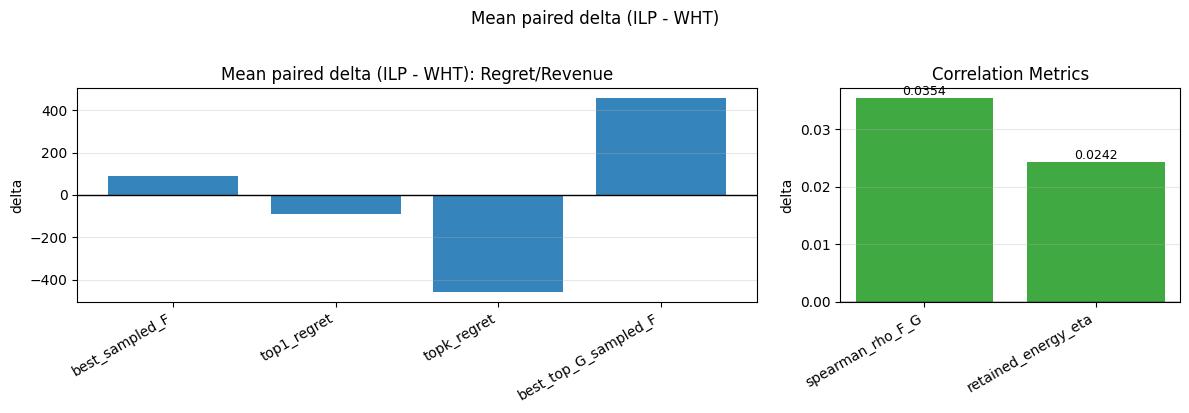

In [6]:
pairing_unavailable_reason = globals().get("pairing_unavailable_reason")

if mix.empty or "encoding" not in mix.columns:
    paired = pd.DataFrame()
elif "pair_keys" not in globals() or not pair_keys:
    paired = pd.DataFrame()
elif pairing_unavailable_reason:
    paired = pd.DataFrame()
else:
    pairing_mix = ensure_run_status_norm(mix.copy())
    wht_source = pairing_mix[
        (pairing_mix["encoding"] == "wht_truncated")
        & (pairing_mix["run_status_norm"] == "completed")
    ].copy()
    ilp_source = pairing_mix[
        (pairing_mix["encoding"] == "ilp_derived")
        & (pairing_mix["run_status_norm"] == "completed")
    ].copy()
    if pair_keys == ["comparison_key"]:
        wht_source = wht_source[wht_source["comparison_key"].notna()].copy()
        ilp_source = ilp_source[ilp_source["comparison_key"].notna()].copy()
    paired = wht_source.merge(
        ilp_source,
        on=pair_keys,
        suffixes=("_wht", "_ilp"),
        how="inner",
    )

if paired.empty:
    reason = "No matched WHT vs ILP records available."
    if pairing_unavailable_reason:
        reason = pairing_unavailable_reason
    elif "pair_keys" not in globals() or not pair_keys:
        reason = "Pairing keys are unavailable; cannot build WHT vs ILP matched deltas."
    display(unavailable_panel_table(
        panel="Paired delta table",
        reason=reason,
    ))
    delta_df = pd.DataFrame()
else:
    delta_rows = []
    for metric in metric_panel:
        w_col = f"{metric}_wht"
        i_col = f"{metric}_ilp"
        if w_col not in paired.columns:
            paired[w_col] = np.nan
        if i_col not in paired.columns:
            paired[i_col] = np.nan
        w = pd.to_numeric(paired[w_col], errors="coerce")
        i = pd.to_numeric(paired[i_col], errors="coerce")
        valid = (~w.isna()) & (~i.isna())
        if valid.any():
            d = i[valid] - w[valid]
            delta_rows.append({
                "metric": metric,
                "paired_n": int(valid.sum()),
                "mean_delta_ilp_minus_wht": float(d.mean()),
                "median_delta_ilp_minus_wht": float(d.median()),
                "status": "available",
            })
        else:
            delta_rows.append({
                "metric": metric,
                "paired_n": 0,
                "mean_delta_ilp_minus_wht": np.nan,
                "median_delta_ilp_minus_wht": np.nan,
                "status": "unavailable",
            })

    delta_df = pd.DataFrame(delta_rows)
    display(delta_df)

# Split metrics into two groups due to scale difference:
# - Large-scale metrics: regret/revenue values in hundreds
# - Correlation metrics: values in [0, 1] range with small deltas
large_scale_metrics = ["best_sampled_F", "top1_regret", "topk_regret", "best_top_G_sampled_F"]
correlation_metrics = ["spearman_rho_F_G", "retained_energy_eta"]

if delta_df.empty:
    placeholder_plot("Paired Delta Overview", "No paired rows to plot.")
    plt.show()
else:
    large_df = delta_df[delta_df["metric"].isin(large_scale_metrics) & (delta_df["status"] == "available")].copy()
    corr_df = delta_df[delta_df["metric"].isin(correlation_metrics) & (delta_df["status"] == "available")].copy()

    if large_df.empty and corr_df.empty:
        placeholder_plot("Paired Delta Overview", "Requested plot metrics are unavailable.")
        plt.show()
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [2, 1]})

        # Left panel: large-scale metrics (regret/revenue)
        ax1 = axes[0]
        if not large_df.empty:
            ax1.bar(large_df["metric"], large_df["mean_delta_ilp_minus_wht"], color="#1f77b4", alpha=0.9)
            ax1.axhline(0.0, color="black", linewidth=1)
            ax1.set_title("Mean paired delta (ILP - WHT): Regret/Revenue")
            ax1.set_ylabel("delta")
            ax1.set_xticks(range(len(large_df)))
            ax1.set_xticklabels(large_df["metric"], rotation=30, ha="right")
            ax1.grid(axis="y", alpha=0.3)
        else:
            ax1.text(0.5, 0.5, "No large-scale metrics available", ha="center", va="center", transform=ax1.transAxes)
            ax1.set_title("Mean paired delta: Regret/Revenue")

        # Right panel: correlation metrics (0-1 scale)
        ax2 = axes[1]
        if not corr_df.empty:
            ax2.bar(corr_df["metric"], corr_df["mean_delta_ilp_minus_wht"], color="#2ca02c", alpha=0.9)
            ax2.axhline(0.0, color="black", linewidth=1)
            ax2.set_title("Correlation Metrics")
            ax2.set_ylabel("delta")
            ax2.set_xticks(range(len(corr_df)))
            ax2.set_xticklabels(corr_df["metric"], rotation=30, ha="right")
            ax2.grid(axis="y", alpha=0.3)
            # Add value annotations for small deltas
            for i, (_, row) in enumerate(corr_df.iterrows()):
                val = row["mean_delta_ilp_minus_wht"]
                ax2.annotate(f"{val:.4f}", (i, val), ha="center", va="bottom" if val > 0 else "top", fontsize=9)
        else:
            ax2.text(0.5, 0.5, "No correlation metrics available", ha="center", va="center", transform=ax2.transAxes)
            ax2.set_title("Correlation Metrics")

        fig.suptitle("Mean paired delta (ILP - WHT)", fontsize=12, y=1.02)
        fig.tight_layout()
        plt.show()

## Unavailable / Skipped Cases


In [7]:
status_cols = [
    c for c in [
        "run_id", "instance_id", "encoding", "decoder", "alpha_mode", "execution_mode", "execution_mode_norm", "run_status", "run_status_norm", "run_error"
    ] if c in focus.columns
]
issue_rows = focus[focus["run_status_norm"] != "completed"][status_cols].copy() if (not focus.empty and "run_status_norm" in focus.columns) else pd.DataFrame()

unavailable_rows = []
for _, row in mix.iterrows():
    avail = row.get("metric_availability_dict", {})
    if not isinstance(avail, dict):
        continue
    for metric, status in avail.items():
        if status != "available":
            unavailable_rows.append({
                "run_id": row.get("run_id"),
                "instance_id": row.get("instance_id"),
                "encoding": row.get("encoding"),
                "decoder": row.get("decoder"),
                "alpha_mode": row.get("alpha_mode"),
                "metric": metric,
                "status": status,
            })

unavailable_df = pd.DataFrame(unavailable_rows)

if issue_rows.empty and unavailable_df.empty:
    display(pd.DataFrame([{"status": "none", "details": "No unavailable/skipped cases in Matrix A focus slice."}]))
else:
    if not issue_rows.empty:
        display(issue_rows)
    if not unavailable_df.empty:
        display(unavailable_df)


,status,details
0,none,No unavailable/skipped cases in Matrix A focus...


## Reviewer Verdict


In [8]:
matched_instance_ids = []
if "paired" in globals() and not paired.empty and "instance_id_wht" in paired.columns:
    matched_instance_ids = sorted(paired["instance_id_wht"].dropna().astype(str).unique().tolist())
elif "matched_keys" in globals() and not matched_keys.empty and "instance_id" in matched_keys.columns:
    matched_instance_ids = sorted(matched_keys["instance_id"].dropna().astype(str).unique().tolist())

p7_candidate_rows = 0
if "mix" in globals() and not mix.empty and "instance_id" in mix.columns and "encoding" in mix.columns:
    p7_candidate_rows = int(
        mix[
            (mix["instance_id"].astype(str) == "P7")
            & (mix["encoding"].isin(["wht_truncated", "ilp_derived"]))
        ].shape[0]
    )

if paired_summary_df.empty or delta_df.empty:
    verdict_lines = [
        "- Paired comparison is unavailable or partial in the current canonical master, so this notebook shows no winner and keeps the recommendation neutral.",
    ]
else:
    verdict_lines = [
        f"- Canonical paired comparison includes {len(matched_instance_ids) or 0} pricing instance(s): {', '.join(matched_instance_ids) if matched_instance_ids else 'none'}.",
        f"- Matched completed record count: {int(len(paired))}.",
        "- Exact-reference / ILP-derived remains the reviewer-facing benchmark backend for the matched pricing slice in the current canonical master.",
        "- WHT remains an exploratory backend and is shown after the exact-reference path in summary tables.",
    ]

if "P7" not in matched_instance_ids:
    verdict_lines.append(
        "- P7 (n=14) is excluded from this paired comparison because no completed matched DQI rows are present in the current canonical master; see Notebook 13 for encoding diagnostics and tractability/resource analysis at n=14."
    )

display(Markdown("\n".join(verdict_lines)))


- Canonical paired comparison includes 3 pricing instance(s): P3, P4, P5.
- Matched completed record count: 18.
- Exact-reference / ILP-derived remains the reviewer-facing benchmark backend for the matched pricing slice in the current canonical master.
- WHT remains an exploratory backend and is shown after the exact-reference path in summary tables.
- P7 (n=14) is excluded from this paired comparison because no completed matched DQI rows are present in the current canonical master; see Notebook 13 for encoding diagnostics and tractability/resource analysis at n=14.

## Scope note

Coherent execution validation for Family C instances is covered in [Notebook 08b](08b_coherent_validation.ipynb).